In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline 

from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)
from sklearn import datasets, ensemble


# Preprocessing 

In [2]:
df = pd.read_csv("cars_data.csv",encoding="ISO-8859-1")
df


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm
...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,"$43,590  $48,000",Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,"$50,000",Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,"$25,210  $29,135",Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec," 33,000",Hybrid,5,190  205 Nm


In [3]:
df["Cars Prices"].unique()

<StringArray>
[            '$1,100,000 ',               '$460,000 ',
         '$12,000-$15,000',               '$161,000 ',
               '$253,290 ',               '$499,000 ',
               '$193,440 ',               '$311,000 ',
             '$4,500,000 ',               '$280,000 ',
 ...
       '$20,000 - $24,000',       '$20,000 - $22,000',
       '$28,000 - $32,000',       '$13,000 - $16,000',
       '$14,000 - $16,000', '$5,000,000 - $7,000,000',
       '$43,590  $48,000',       '$25,210  $29,135',
                ' 33,000',       '$29,000  $43,000']
Length: 535, dtype: str

In [4]:
import re 


def clean_text(x):
    x = str(x)

    x = x.replace(",", "")

    numbers = re.findall(r"\d+", x)

    if len(numbers) >= 2:
        low = float(numbers[0])
        high = float(numbers[1])
        return (low + high) / 2

    elif len(numbers) == 1:
        return float(numbers[0])

    return np.nan

    
    
df["Cars Prices"] = df["Cars Prices"].apply(clean_text)


In [5]:
clean_text("$12,000-$15,000")

13500.0

In [6]:
import re

x = "$12,000-$15,000"

x = x.replace(",", "")

print(x)

print(re.findall(r"\d+", x))

$12000-$15000
['12000', '15000']


In [7]:
df

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,1100000.0,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,460000.0,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,13500.0,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,161000.0,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,253290.0,Petrol,2,560 Nm
...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,45795.0,Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,50000.0,Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,27172.5,Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec,33000.0,Hybrid,5,190  205 Nm


In [8]:
df.tail()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,45795.0,Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,50000.0,Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,27172.5,Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec,33000.0,Hybrid,5,190  205 Nm
1217,Toyota,RAV4 (6th Gen),2.5L Hybrid / Plug-in Hybrid,2487 cc + batt,219  302 hp,200 km/h,6.0  8.1 sec,36000.0,Hybrid / Plug-in,5,221  400 Nm


In [9]:
df["Cars Prices"] = df["Cars Prices"].astype(float)

In [10]:
df.tail()


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,45795.0,Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,50000.0,Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,27172.5,Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec,33000.0,Hybrid,5,190  205 Nm
1217,Toyota,RAV4 (6th Gen),2.5L Hybrid / Plug-in Hybrid,2487 cc + batt,219  302 hp,200 km/h,6.0  8.1 sec,36000.0,Hybrid / Plug-in,5,221  400 Nm


In [11]:
df["Total Speed"] = df["Total Speed"].apply(clean_text)

In [12]:
df

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340.0,2.5 sec,1100000.0,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250.0,5.3 sec,460000.0,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165.0,10.5 sec,13500.0,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250.0,3.2 sec,161000.0,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320.0,3.6 sec,253290.0,Petrol,2,560 Nm
...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180.0,7.6 sec,45795.0,Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180.0,6.8 sec,50000.0,Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190.0,8.0  9.2 sec,27172.5,Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180.0,7.9  10.5 sec,33000.0,Hybrid,5,190  205 Nm


In [13]:
df["Total Speed"] = df["Total Speed"].astype(float)

In [14]:
df["Total Speed"].dtype

dtype('float64')

In [15]:
df["HorsePower"] = df["HorsePower"].apply(clean_text)

In [16]:
df["HorsePower"] = df["HorsePower"].astype(float)

In [17]:
df

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963.0,340.0,2.5 sec,1100000.0,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563.0,250.0,5.3 sec,460000.0,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",77.5,165.0,10.5 sec,13500.0,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630.0,250.0,3.2 sec,161000.0,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602.0,320.0,3.6 sec,253290.0,Petrol,2,560 Nm
...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240.0,180.0,7.6 sec,45795.0,Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326.0,180.0,6.8 sec,50000.0,Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,182.5,190.0,8.0  9.2 sec,27172.5,Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,169.0,180.0,7.9  10.5 sec,33000.0,Hybrid,5,190  205 Nm


In [18]:
df["Performance(0 - 100 )KM/H"] = df["Performance(0 - 100 )KM/H"].apply(clean_text)

In [19]:
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963.0,340.0,3.5,1100000.0,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563.0,250.0,4.0,460000.0,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",77.5,165.0,7.5,13500.0,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630.0,250.0,2.5,161000.0,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602.0,320.0,4.5,253290.0,Petrol,2,560 Nm


In [20]:
company_name = df["Company Names"]

In [21]:
df["Performance(0 - 100 )KM/H"] = df["Performance(0 - 100 )KM/H"].astype(float)

In [22]:
df["Torque"] = df["Torque"].apply(clean_text)

In [23]:
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963.0,340.0,3.5,1100000.0,plug in hyrbrid,2,800.0
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563.0,250.0,4.0,460000.0,Petrol,5,900.0
2,Ford,KA+,1.2L Petrol,"1,200 cc",77.5,165.0,7.5,13500.0,Petrol,5,120.0
3,MERCEDES,GT 63 S,V8,"3,982 cc",630.0,250.0,2.5,161000.0,Petrol,4,900.0
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602.0,320.0,4.5,253290.0,Petrol,2,560.0


In [24]:
df["Torque"] = df["Torque"].astype(float)

In [25]:
df["Fuel Types"].unique()

<StringArray>
[        'plug in hyrbrid',                  'Petrol',
                  'Diesel',                  'Hybrid',
                'Electric',           'Petrol/Diesel',
          'Plug-in Hybrid',              'Petrol/AWD',
           'Petrol/Hybrid',                'Hydrogen',
           'Diesel/Petrol',               'Petrol/EV',
         'Hybrid/Electric',          'Petrol, Hybrid',
          'Petrol, Diesel',         'Hybrid (Petrol)',
              'CNG/Petrol',           'Hybrid/Petrol',
           'Diesel Hybrid',         'Petrol (Hybrid)',
 'Hybrid (Gas + Electric)',            'Gas / Hybrid',
        'Hybrid / Plug-in']
Length: 23, dtype: str

In [26]:
df["CC/Battery Capacity"].unique()

<StringArray>
[              '3990 cc',               '6749 cc',              '1,200 cc',
              '3,982 cc',              '5,204 cc',              '3,994 cc',
              '3,996 cc',              '6,498 cc',              '3,900 cc',
               '6496 cc',
 ...
              '1,588 cc',              '1,590 cc',                '360 cc',
              '1,298 cc',              '2,620 cc',               '2487 cc',
     '2393 cc + Battery', '1987 cc / Hybrid batt', '1798 / 1987 cc + batt',
        '2487 cc + batt']
Length: 312, dtype: str

In [27]:
df = df.drop("Cars Names", axis=1)

In [28]:
df.head()

,Company Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,V8,3990 cc,963.0,340.0,3.5,1100000.0,plug in hyrbrid,2,800.0
1,ROLLS ROYCE,V12,6749 cc,563.0,250.0,4.0,460000.0,Petrol,5,900.0
2,Ford,1.2L Petrol,"1,200 cc",77.5,165.0,7.5,13500.0,Petrol,5,120.0
3,MERCEDES,V8,"3,982 cc",630.0,250.0,2.5,161000.0,Petrol,4,900.0
4,AUDI,V10,"5,204 cc",602.0,320.0,4.5,253290.0,Petrol,2,560.0


In [29]:
df

,Company Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,V8,3990 cc,963.0,340.0,3.5,1100000.0,plug in hyrbrid,2,800.0
1,ROLLS ROYCE,V12,6749 cc,563.0,250.0,4.0,460000.0,Petrol,5,900.0
2,Ford,1.2L Petrol,"1,200 cc",77.5,165.0,7.5,13500.0,Petrol,5,120.0
3,MERCEDES,V8,"3,982 cc",630.0,250.0,2.5,161000.0,Petrol,4,900.0
4,AUDI,V10,"5,204 cc",602.0,320.0,4.5,253290.0,Petrol,2,560.0
...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,2.5L Hybrid I4,2487 cc,240.0,180.0,6.5,45795.0,Hybrid (Gas + Electric),5,239.0
1214,Toyota,2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326.0,180.0,7.0,50000.0,Hybrid,7,630.0
1215,Toyota,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,182.5,190.0,4.0,27172.5,Gas / Hybrid,5,200.0
1216,Toyota,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,169.0,180.0,8.0,33000.0,Hybrid,5,197.5


In [30]:
df["CC/Battery Capacity"].unique()

<StringArray>
[              '3990 cc',               '6749 cc',              '1,200 cc',
              '3,982 cc',              '5,204 cc',              '3,994 cc',
              '3,996 cc',              '6,498 cc',              '3,900 cc',
               '6496 cc',
 ...
              '1,588 cc',              '1,590 cc',                '360 cc',
              '1,298 cc',              '2,620 cc',               '2487 cc',
     '2393 cc + Battery', '1987 cc / Hybrid batt', '1798 / 1987 cc + batt',
        '2487 cc + batt']
Length: 312, dtype: str

In [31]:
def clean_CC(x):
    x = str(x)
    x= x.replace(",","")

    number = re.findall(r"\d+",x)

    if number : 
        number = [float(num) for num in number]
        return max(number)

    return np.nan

In [32]:
df["Is_hybrid "] = df["CC/Battery Capacity"].str.contains(
    "Battery|batt|Hybrid",
    case =False,
    na = False
)

In [33]:
df.head()

df["CC/Battery Capacity"] = df["CC/Battery Capacity"].apply(clean_CC)

In [34]:
df

,Company Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque,Is_hybrid
0,FERRARI,V8,3990.0,963.0,340.0,3.5,1100000.0,plug in hyrbrid,2,800.0,False
1,ROLLS ROYCE,V12,6749.0,563.0,250.0,4.0,460000.0,Petrol,5,900.0,False
2,Ford,1.2L Petrol,1200.0,77.5,165.0,7.5,13500.0,Petrol,5,120.0,False
3,MERCEDES,V8,3982.0,630.0,250.0,2.5,161000.0,Petrol,4,900.0,False
4,AUDI,V10,5204.0,602.0,320.0,4.5,253290.0,Petrol,2,560.0,False
...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,2.5L Hybrid I4,2487.0,240.0,180.0,6.5,45795.0,Hybrid (Gas + Electric),5,239.0,False
1214,Toyota,2.4L Turbo I4 (i-FORCE MAX Hybrid),2393.0,326.0,180.0,7.0,50000.0,Hybrid,7,630.0,True
1215,Toyota,2.0L Gas / 2.0L Hybrid,1987.0,182.5,190.0,4.0,27172.5,Gas / Hybrid,5,200.0,True
1216,Toyota,1.8L / 2.0L Hybrid,1987.0,169.0,180.0,8.0,33000.0,Hybrid,5,197.5,True


In [35]:
df["Fuel Types"].unique()

<StringArray>
[        'plug in hyrbrid',                  'Petrol',
                  'Diesel',                  'Hybrid',
                'Electric',           'Petrol/Diesel',
          'Plug-in Hybrid',              'Petrol/AWD',
           'Petrol/Hybrid',                'Hydrogen',
           'Diesel/Petrol',               'Petrol/EV',
         'Hybrid/Electric',          'Petrol, Hybrid',
          'Petrol, Diesel',         'Hybrid (Petrol)',
              'CNG/Petrol',           'Hybrid/Petrol',
           'Diesel Hybrid',         'Petrol (Hybrid)',
 'Hybrid (Gas + Electric)',            'Gas / Hybrid',
        'Hybrid / Plug-in']
Length: 23, dtype: str

In [36]:
df["Fuel Types"] = df["Fuel Types"].str.lower()

In [37]:
df["Is_Petrol"] = df["Fuel Types"].str.contains("petrol", na = False)
df["Is_Diesel"] = df["Fuel Types"].str.contains("diesel", na = False)
df["Is_Hybrid"] = df["Fuel Types"].str.contains("hybrid|hyrbrid", na = False)
df["Is_Electric"] = df["Fuel Types"].str.contains("electric|ev", na = False)
df["Is_CNG"] = df["Fuel Types"].str.contains("cng", na = False)
df["Is_Electric"] = df["Fuel Types"].str.contains("electric|ev", na = False)
df["Is_Hydrogen"] = df["Fuel Types"].str.contains("hydrogen", na = False)


In [38]:
df = df.drop("Is_hybrid ", axis=1)

In [39]:
df = df.drop("Fuel Types" , axis=1)


In [40]:
df["CC/Battery Capacity"].max

<bound method Series.max of 0       3990.0
1       6749.0
2       1200.0
3       3982.0
4       5204.0
         ...  
1213    2487.0
1214    2393.0
1215    1987.0
1216    1987.0
1217    2487.0
Name: CC/Battery Capacity, Length: 1218, dtype: float64>

In [41]:
df["Engines"].unique()

<StringArray>
[                                'V8',                                'V12',
                        '1.2L Petrol',                                'V10',
                                 'I4',                            'BOXER-4',
                                 'V6',                     'ELECTRIC MOTOR',
                                 'I6',                          'ELECTRIC ',
 ...
             '1.3L Wankel + Electric',                     '0.36L Inline-2',
                     '0.66L Inline-3',          '1.3L Wankel Rotary Engine',
          '2.6L Wankel Rotary Engine',                     '2.5L Hybrid I4',
 '2.4L Turbo I4 (i-FORCE MAX Hybrid)',             '2.0L Gas / 2.0L Hybrid',
                 '1.8L / 2.0L Hybrid',       '2.5L Hybrid / Plug-in Hybrid']
Length: 356, dtype: str

In [42]:
def extract_cylinder(x):
    x= str(x).upper()
    match = re.search(r"[VI](\d+)",x)
    if not match:
        match = re.search(r"(BOXER|INLINE)[-\s]?(\d+)", x)
        if match:
            return float(match.group(2))
    else:
        return float(match.group(1))
    return np.nan
     

In [43]:
df["cylinder"] = df["Engines"].apply(extract_cylinder)

In [44]:
df["cylinder"].unique()

array([ 8., 12., nan, 10.,  4.,  6.,  3.,  2.])

In [45]:
df["Engines"].isna().sum()

np.int64(0)

In [46]:
df.drop("Engines", axis=1)

,Company Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,FERRARI,3990.0,963.0,340.0,3.5,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,ROLLS ROYCE,6749.0,563.0,250.0,4.0,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,Ford,1200.0,77.5,165.0,7.5,13500.0,5,120.0,True,False,False,False,False,False,NaN
3,MERCEDES,3982.0,630.0,250.0,2.5,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,AUDI,5204.0,602.0,320.0,4.5,253290.0,2,560.0,True,False,False,False,False,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,2487.0,240.0,180.0,6.5,45795.0,5,239.0,False,False,True,True,False,False,4.0
1214,Toyota,2393.0,326.0,180.0,7.0,50000.0,7,630.0,False,False,True,False,False,False,4.0
1215,Toyota,1987.0,182.5,190.0,4.0,27172.5,5,200.0,False,False,True,False,False,False,NaN
1216,Toyota,1987.0,169.0,180.0,8.0,33000.0,5,197.5,False,False,True,False,False,False,NaN


In [47]:
df["cylinder"] = df["cylinder"].fillna(df["cylinder"].median())

In [48]:
df["cylinder"].unique()

array([ 8., 12.,  6., 10.,  4.,  3.,  2.])

In [49]:
df["cylinder"].isna().sum()

np.int64(0)

In [50]:
df = df.drop("Engines", axis=1)

In [51]:
df

,Company Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,FERRARI,3990.0,963.0,340.0,3.5,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,ROLLS ROYCE,6749.0,563.0,250.0,4.0,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,Ford,1200.0,77.5,165.0,7.5,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,MERCEDES,3982.0,630.0,250.0,2.5,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,AUDI,5204.0,602.0,320.0,4.5,253290.0,2,560.0,True,False,False,False,False,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,2487.0,240.0,180.0,6.5,45795.0,5,239.0,False,False,True,True,False,False,4.0
1214,Toyota,2393.0,326.0,180.0,7.0,50000.0,7,630.0,False,False,True,False,False,False,4.0
1215,Toyota,1987.0,182.5,190.0,4.0,27172.5,5,200.0,False,False,True,False,False,False,6.0
1216,Toyota,1987.0,169.0,180.0,8.0,33000.0,5,197.5,False,False,True,False,False,False,6.0


In [52]:
df["Company Names"].unique()

<StringArray>
[          'FERRARI',       'ROLLS ROYCE',              'Ford',
          'MERCEDES',              'AUDI',               'BMW',
      'ASTON MARTIN',           'BENTLEY',       'LAMBORGHINI',
            'TOYOTA',            'NISSAN',      'ROLLS ROYCE ',
             'VOLVO',               'KIA',             'HONDA',
             'KIA  ',           'HYUNDAI',          'MAHINDRA',
     'MARUTI SUZUKI',            'Nissan',        'Volkswagen',
           'Porsche',          'Cadillac',       'Tata Motors',
             'Tesla',              'Jeep',             'Mazda',
         'Chevrolet',               'GMC',               'Kia',
           'Peugeot',           'Bugatti',             'Volvo',
 'Jaguar Land Rover',             'Acura',        'Mitsubishi',
            'Toyota']
Length: 37, dtype: str

In [53]:
df["Company Names"] = (
    df["Company Names"]
    .str.strip()
    .str.title()
)

In [54]:
df

,Company Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,Ferrari,3990.0,963.0,340.0,3.5,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,Rolls Royce,6749.0,563.0,250.0,4.0,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,Ford,1200.0,77.5,165.0,7.5,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,Mercedes,3982.0,630.0,250.0,2.5,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,Audi,5204.0,602.0,320.0,4.5,253290.0,2,560.0,True,False,False,False,False,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,2487.0,240.0,180.0,6.5,45795.0,5,239.0,False,False,True,True,False,False,4.0
1214,Toyota,2393.0,326.0,180.0,7.0,50000.0,7,630.0,False,False,True,False,False,False,4.0
1215,Toyota,1987.0,182.5,190.0,4.0,27172.5,5,200.0,False,False,True,False,False,False,6.0
1216,Toyota,1987.0,169.0,180.0,8.0,33000.0,5,197.5,False,False,True,False,False,False,6.0


In [55]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Company Names"]

one_hot = OneHotEncoder()

transformer = ColumnTransformer([("one_hot", one_hot , categorical_features)],
                               remainder="passthrough")

transformed_X = transformer.fit_transform(df)

encoded_df =  pd.DataFrame(
    transformed_X,
    columns = transformer.get_feature_names_out()
)

In [56]:
df_without_name=df

In [57]:
df = encoded_df

In [58]:
df.columns = (

    df.columns

    .str.replace("one_hot__", "", regex=False)

    .str.replace("Company Names_", "", regex=False)
    .str.replace("remainder__", "" ,regex = False)

)

In [59]:
df


,Acura,Aston Martin,Audi,Bentley,Bmw,Bugatti,Cadillac,Chevrolet,Ferrari,Ford,...,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253290.0,2,560.0,True,False,False,False,False,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,45795.0,5,239.0,False,False,True,True,False,False,4.0
1214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,50000.0,7,630.0,False,False,True,False,False,False,4.0
1215,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,27172.5,5,200.0,False,False,True,False,False,False,6.0
1216,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,33000.0,5,197.5,False,False,True,False,False,False,6.0


In [60]:
df_without_name

,Company Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,Ferrari,3990.0,963.0,340.0,3.5,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,Rolls Royce,6749.0,563.0,250.0,4.0,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,Ford,1200.0,77.5,165.0,7.5,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,Mercedes,3982.0,630.0,250.0,2.5,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,Audi,5204.0,602.0,320.0,4.5,253290.0,2,560.0,True,False,False,False,False,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,2487.0,240.0,180.0,6.5,45795.0,5,239.0,False,False,True,True,False,False,4.0
1214,Toyota,2393.0,326.0,180.0,7.0,50000.0,7,630.0,False,False,True,False,False,False,4.0
1215,Toyota,1987.0,182.5,190.0,4.0,27172.5,5,200.0,False,False,True,False,False,False,6.0
1216,Toyota,1987.0,169.0,180.0,8.0,33000.0,5,197.5,False,False,True,False,False,False,6.0


In [61]:
df["Seats"].unique()

<StringArray>
[   '2',    '5',    '4',  '2+2',    '7',    '8',   '20',   '15',   '12',
    '3',    '9',    '6',    '1', '215',  '27',  '26',  '78',  '29',
 '212']
Length: 19, dtype: str

In [62]:
def clean_seats(x):

    x = str(x)

    x = x.replace("", "-")

    if "+" in x:
        nums = re.findall(r"\d+", x)
        return sum(map(int, nums))
    if "-" in x:
        nums = re.findall(r"\d+", x)

        return max(map(int, nums))
    nums = re.findall(r"\d+", x)
    if nums:
        return int(nums[0])
    return np.nan

In [63]:
df["Seats"] = df["Seats"].apply(clean_seats)

In [64]:
df["Seats"].unique()

array([ 2,  5,  4,  7,  8, 20, 15, 12,  3,  9,  6,  1])

In [65]:

df_without_name

,Company Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,Ferrari,3990.0,963.0,340.0,3.5,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,Rolls Royce,6749.0,563.0,250.0,4.0,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,Ford,1200.0,77.5,165.0,7.5,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,Mercedes,3982.0,630.0,250.0,2.5,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,Audi,5204.0,602.0,320.0,4.5,253290.0,2,560.0,True,False,False,False,False,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,2487.0,240.0,180.0,6.5,45795.0,5,239.0,False,False,True,True,False,False,4.0
1214,Toyota,2393.0,326.0,180.0,7.0,50000.0,7,630.0,False,False,True,False,False,False,4.0
1215,Toyota,1987.0,182.5,190.0,4.0,27172.5,5,200.0,False,False,True,False,False,False,6.0
1216,Toyota,1987.0,169.0,180.0,8.0,33000.0,5,197.5,False,False,True,False,False,False,6.0


In [66]:
def clean_seats(x):
    x= str(x)

    if "+" in x:
        nums = re.findall(r"/d+", x)
        return sum(nums)
    if "-" in x:
        nums = re.findall(r"/d+", x)
        return max(map(int , nums))
    nums = re.findall(r"\d+", x)
    if nums:
        return int(nums[0])
        

In [67]:
df_without_name["Seats"] = df_without_name["Seats"].apply(clean_seats)
df_without_name= df_without_name.drop("Company Names", axis=1)
df_without_name

,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,3990.0,963.0,340.0,3.5,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,6749.0,563.0,250.0,4.0,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,1200.0,77.5,165.0,7.5,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,3982.0,630.0,250.0,2.5,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,5204.0,602.0,320.0,4.5,253290.0,2,560.0,True,False,False,False,False,False,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,2487.0,240.0,180.0,6.5,45795.0,5,239.0,False,False,True,True,False,False,4.0
1214,2393.0,326.0,180.0,7.0,50000.0,7,630.0,False,False,True,False,False,False,4.0
1215,1987.0,182.5,190.0,4.0,27172.5,5,200.0,False,False,True,False,False,False,6.0
1216,1987.0,169.0,180.0,8.0,33000.0,5,197.5,False,False,True,False,False,False,6.0


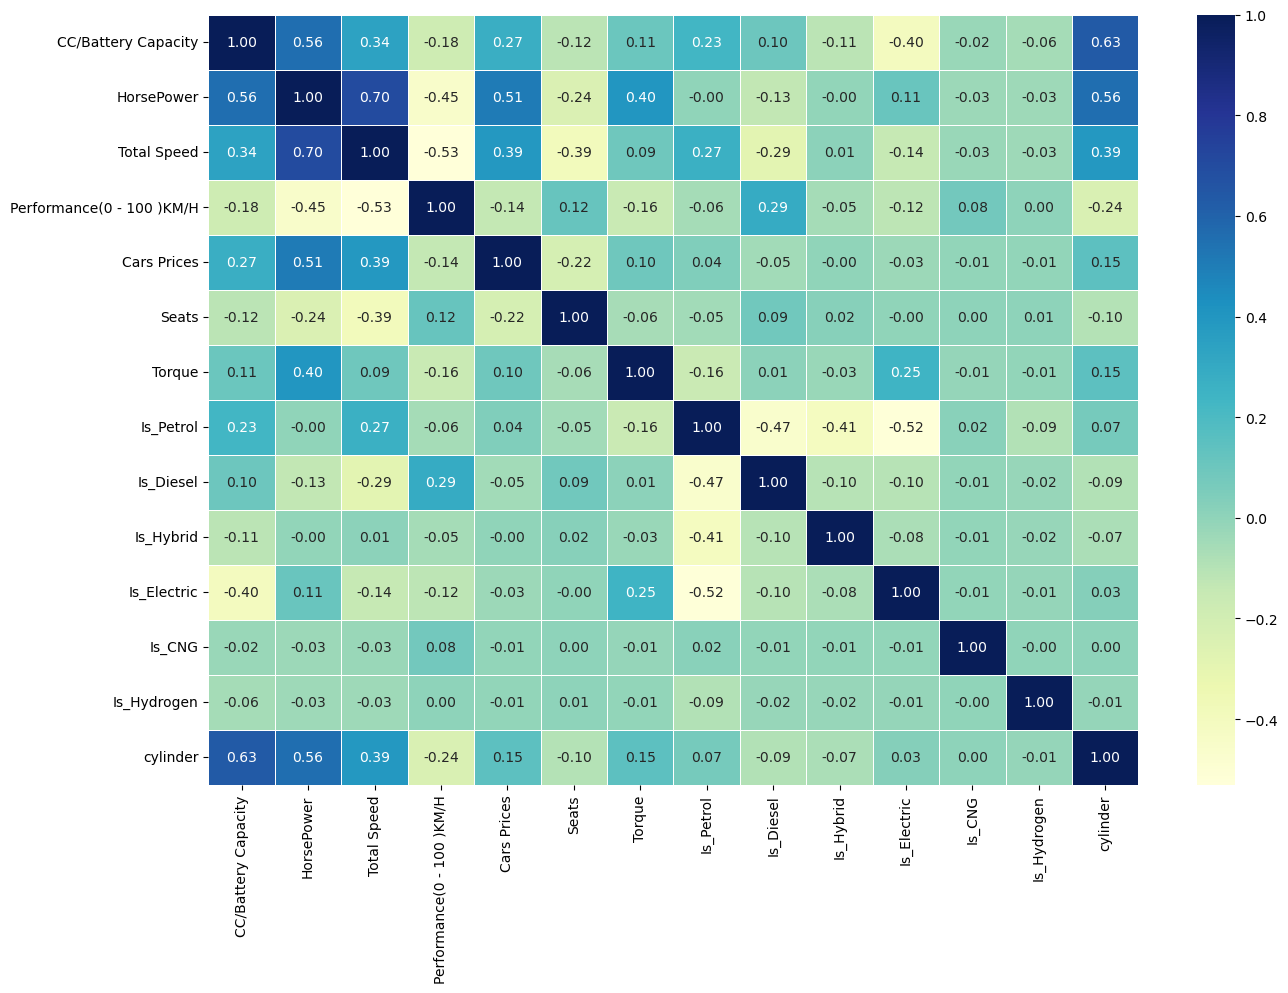

In [68]:

corr_matrix= df_without_name.corr()

fig, ax = plt.subplots(figsize=(15,10))

ax = sns.heatmap(corr_matrix,
                annot =True,
                linewidths= 0.5,
                fmt =".2f",
                cmap = "YlGnBu")

<Axes: xlabel='HorsePower', ylabel='Cars Prices'>

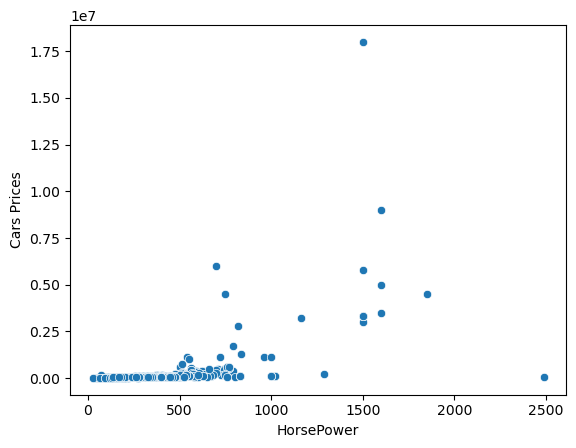

In [69]:
sns.scatterplot(x=df["HorsePower"], y=df["Cars Prices"])
#higher the horse power higher the price we can also see that in corr matrix & that these two metrics are highy related

In [70]:
df_without_name.head()

,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,3990.0,963.0,340.0,3.5,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,6749.0,563.0,250.0,4.0,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,1200.0,77.5,165.0,7.5,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,3982.0,630.0,250.0,2.5,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,5204.0,602.0,320.0,4.5,253290.0,2,560.0,True,False,False,False,False,False,10.0


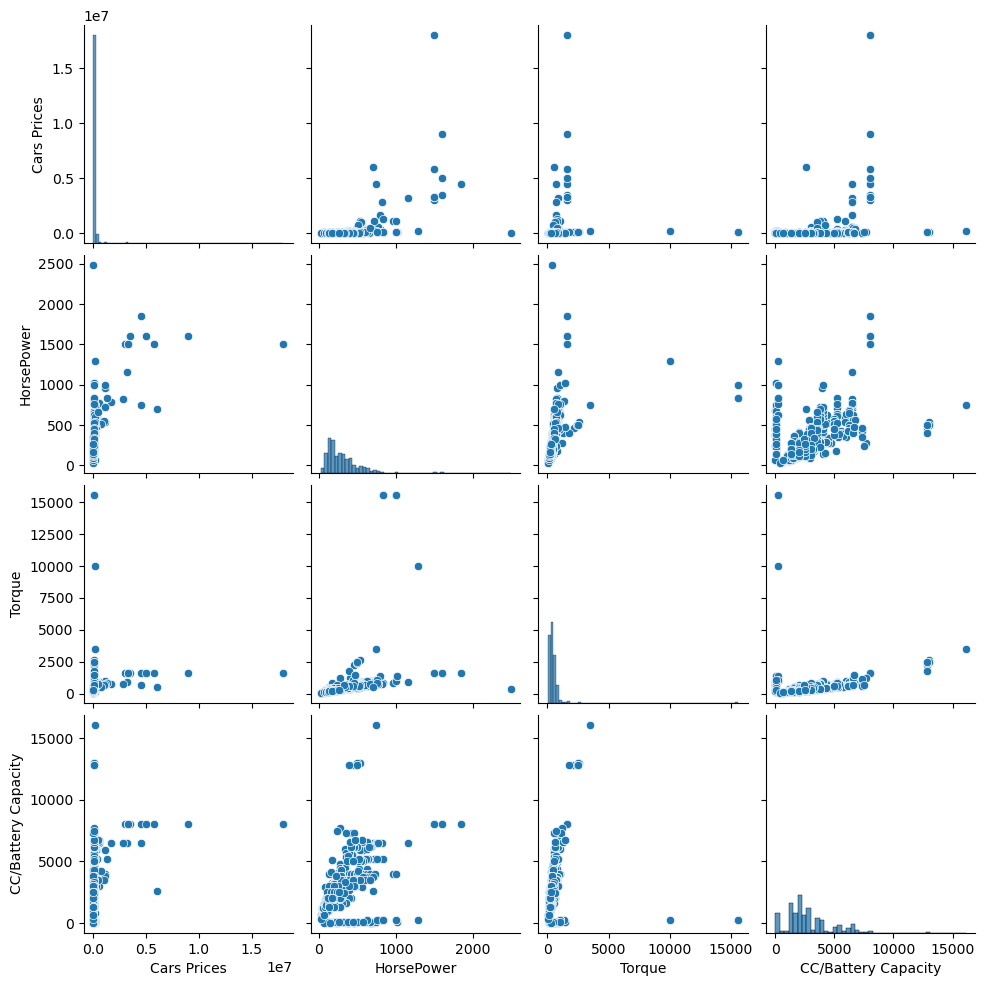

In [71]:
sns.pairplot(
    df[["Cars Prices", "HorsePower", "Torque", "CC/Battery Capacity"]]
)

<Axes: xlabel='Cars Prices', ylabel='Density'>

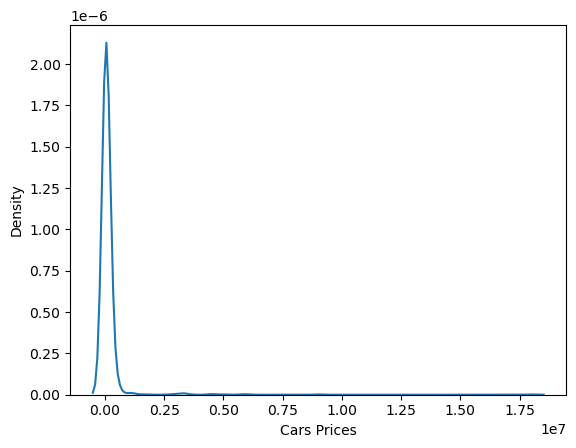

In [72]:
sns.kdeplot(df["Cars Prices"])

In [73]:
df["Cars Prices"] = df["Cars Prices"].astype(float)
df["Cars Prices"].dtype

dtype('float64')

In [74]:
df["Log Prices"] = np.log(df["Cars Prices"])
df.head()

,Acura,Aston Martin,Audi,Bentley,Bmw,Bugatti,Cadillac,Chevrolet,Ferrari,Ford,...,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder,Log Prices
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2,800.0,False,False,True,False,False,False,8.0,13.910821
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5,900.0,True,False,False,False,False,False,12.0,13.038982
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,5,120.0,True,False,False,False,False,False,6.0,9.510445
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4,900.0,True,False,False,False,False,False,8.0,11.989160
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2,560.0,True,False,False,False,False,False,10.0,12.442290


<Axes: xlabel='Log Prices', ylabel='Density'>

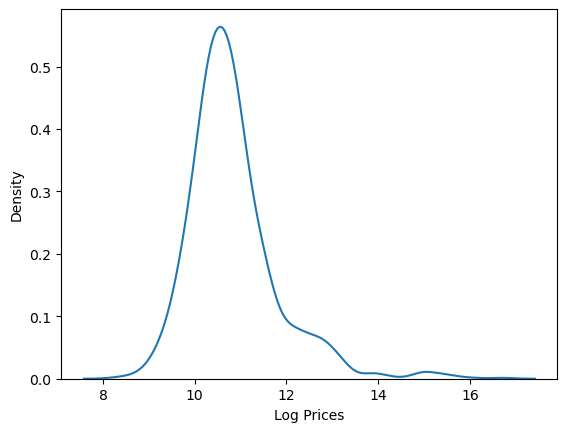

In [75]:
sns.kdeplot(df["Log Prices"])

In [76]:
df= df.drop("Log Prices", axis=1)


In [77]:
df.isna().sum()

Acura                        0
Aston Martin                 0
Audi                         0
Bentley                      0
Bmw                          0
Bugatti                      0
Cadillac                     0
Chevrolet                    0
Ferrari                      0
Ford                         0
Gmc                          0
Honda                        0
Hyundai                      0
Jaguar Land Rover            0
Jeep                         0
Kia                          0
Lamborghini                  0
Mahindra                     0
Maruti Suzuki                0
Mazda                        0
Mercedes                     0
Mitsubishi                   0
Nissan                       0
Peugeot                      0
Porsche                      0
Rolls Royce                  0
Tata Motors                  0
Tesla                        0
Toyota                       0
Volkswagen                   0
Volvo                        0
CC/Battery Capacity          5
HorsePow

In [78]:
df= df.dropna()

In [79]:
df.isna().sum()

Acura                        0
Aston Martin                 0
Audi                         0
Bentley                      0
Bmw                          0
Bugatti                      0
Cadillac                     0
Chevrolet                    0
Ferrari                      0
Ford                         0
Gmc                          0
Honda                        0
Hyundai                      0
Jaguar Land Rover            0
Jeep                         0
Kia                          0
Lamborghini                  0
Mahindra                     0
Maruti Suzuki                0
Mazda                        0
Mercedes                     0
Mitsubishi                   0
Nissan                       0
Peugeot                      0
Porsche                      0
Rolls Royce                  0
Tata Motors                  0
Tesla                        0
Toyota                       0
Volkswagen                   0
Volvo                        0
CC/Battery Capacity          0
HorsePow

In [80]:
upper_limit = df["Cars Prices"].quantile(0.99)

df = df[
    df["Cars Prices"] <= upper_limit
]

In [81]:
x= df.drop("Cars Prices", axis=1)
y = np.log(df["Cars Prices"])
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def random_forest(x ,y) : 
    np.random.seed(41)

    model = RandomForestRegressor(n_estimators=200)
    cross_val= cross_val_score(model, x,y)
    
    return cross_val


In [82]:
from sklearn.ensemble import RandomForestRegressor 

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)




In [83]:
cross_val= cross_val_score(model, x,y)

print ("Cross val score is :", cross_val)
print("Avg Cross val score :" , np.mean(cross_val))


Cross val score is : [0.56181515 0.76525358 0.70751786 0.75484042 0.75852976]
Avg Cross val score : 0.7095913561410797


In [84]:
np.mean(cross_val)

np.float64(0.7095913561410797)

In [85]:
max(df["Cars Prices"])

2800000.0

In [86]:
df.head()

,Acura,Aston Martin,Audi,Bentley,Bmw,Bugatti,Cadillac,Chevrolet,Ferrari,Ford,...,Cars Prices,Seats,Torque,Is_Petrol,Is_Diesel,Is_Hybrid,Is_Electric,Is_CNG,Is_Hydrogen,cylinder
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1100000.0,2,800.0,False,False,True,False,False,False,8.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,460000.0,5,900.0,True,False,False,False,False,False,12.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,13500.0,5,120.0,True,False,False,False,False,False,6.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,161000.0,4,900.0,True,False,False,False,False,False,8.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253290.0,2,560.0,True,False,False,False,False,False,10.0


In [87]:
x= df.drop("Cars Prices", axis=1)
y = np.log(df["Cars Prices"])

x_train , x_test , y_train, y_test = train_test_split(x,y , test_size=0.2)

In [88]:
np.mean(random_forest(x,y))

np.float64(0.7066524628005106)

In [89]:
print(y.min(), y.max())

8.294049640102028 14.845129975145433


In [90]:
rf_grid = {
   "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt"]
}

rf_model = RandomForestRegressor()
    

In [91]:
rs_model = RandomizedSearchCV(rf_model, param_distributions = rf_grid,n_iter=20)

In [92]:
rs_model.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [93]:
rs_model.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [94]:
best_model = rs_model.best_estimator_

In [95]:
best_model.score(x_test,y_test)

0.9162946579529149

In [96]:
cross_score = cross_val_score(best_model, x, y) # tuned one 
np.mean(cross_score)

np.float64(0.7403829324998339)

In [97]:
np.mean(random_forest(x,y)) # baseline one 

np.float64(0.7066524628005106)

In [98]:
y_preds = best_model.predict(x_test) 
y_actual_preds_rf = np.exp(y_preds)
y_actual_test = np.exp(y_test)

MAE= mean_absolute_error(
    y_actual_test,
    y_actual_preds_rf
)

print("Mean Absolute Error : ", MAE)

Mean Absolute Error :  22041.392916897905


In [101]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_actual_test,
    y_actual_preds_rf
)

print(mape)

0.1525666619073969


In [102]:
df["Cars Prices"].mean()

np.float64(79591.60794979079)

In [103]:
df.head()
print(df.columns.tolist())

['Acura', 'Aston Martin', 'Audi', 'Bentley', 'Bmw', 'Bugatti', 'Cadillac', 'Chevrolet', 'Ferrari', 'Ford', 'Gmc', 'Honda', 'Hyundai', 'Jaguar Land Rover', 'Jeep', 'Kia', 'Lamborghini', 'Mahindra', 'Maruti Suzuki', 'Mazda', 'Mercedes', 'Mitsubishi', 'Nissan', 'Peugeot', 'Porsche', 'Rolls Royce', 'Tata Motors', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Seats', 'Torque', 'Is_Petrol', 'Is_Diesel', 'Is_Hybrid', 'Is_Electric', 'Is_CNG', 'Is_Hydrogen', 'cylinder']


## Trying out GradientBoostingRegression 

In [104]:
x= df.drop("Cars Prices", axis=1)
y= np.log(df["Cars Prices"])

params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}
x_train , x_test , y_train, y_test = train_test_split(x,y , test_size=0.2)


reg = ensemble.GradientBoostingRegressor(**params)

reg.fit(x_train, y_train)

reg.score(x_test , y_test)

0.9249011489536457

In [105]:
cross_score = cross_val_score(reg , x,y)
print(cross_score)
print(np.mean(cross_score))


[0.62403566 0.75423886 0.73767772 0.76141498 0.72345685]
0.7201648139974618


In [106]:
y_preds = reg.predict(x_test) 
y_actual_preds_B = np.exp(y_preds)
y_actual_test = np.exp(y_test)

mean_absolute_error(
    y_actual_test,
    y_actual_preds_B
)

21880.59171618969

In [107]:
mse = mean_squared_error(y_preds , y_test)
rmse = np.sqrt(mse)
rmse

np.float64(0.2567877645257212)

In [110]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_actual_test,
    y_actual_preds_B
)

print(mape)

0.18102178696427698


In [ ]:
import joblib

joblib.dump(reg , "XG_boost_car_predictor.pkl")


In [ ]:
joblib.dump(best_model, "Random_Forest_car_price_predictor.pkl")

In [115]:
y_actual_pred_avg = (y_actual_preds_rf+y_actual_preds_B)/2;


In [116]:
mape = mean_absolute_percentage_error(
    y_actual_test,
    y_actual_pred_avg
)
mape


0.782946577448643